In [5]:
import pandas as pd
import numpy as np
from scipy import stats

In [6]:
import pandas as pd
data = pd.read_csv(r"C:\Users\bilge\OneDrive\Masaüstü\data.csv")
data

,Yas,Cinsiyet,Kilo (kg),Boy(m),Max_BPM,Ort_BPM,Dinlenme_BPM,Oturum_Suresi(saat),Yakilan_Kalori,Egzersiz_Turu,Yag_Yuzdesi,Tuketilen_Su(Litre),Antreman_Siklikgi(gun/hafta),Deneyim_Seviyesi,BKE
0,56,Male,88.3,1.71,180,157,60,1.69,1313,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,Male,87.1,1.74,187,158,67,1.57,1364,Strength,10.0,3.5,4,3,28.77
969,25,Male,66.6,1.61,184,166,56,1.38,1260,Strength,25.0,3.0,2,1,25.69
970,59,Female,60.4,1.76,194,120,53,1.72,929,Cardio,18.8,2.7,5,3,19.50
971,32,Male,126.4,1.83,198,146,62,1.10,883,HIIT,28.2,2.1,3,2,37.74


In [7]:
# Sayısal sütunları seç
numeric_data = data.select_dtypes(include=['number'])

# Merkezi Eğilim Ölçüleri ve Dağılım
descriptive_statistics = numeric_data.describe()
descriptive_statistics.loc['Varyans'] = numeric_data.var()
descriptive_statistics.loc['Medyan'] = numeric_data.median()
descriptive_statistics.loc['MAD'] = numeric_data.apply(lambda x: (x - x.mean()).abs().mean())
descriptive_statistics.loc['MED'] = numeric_data.apply(lambda x: (x - x.median()).abs().median())
# Mod değerlerini ekle
mod_values = numeric_data.mode().iloc[0]
descriptive_statistics.loc['Mod'] = mod_values

# Sonuçları yazdırma
print("\nMerkezi Eğilim Ölçüleri ve Dağılım:")
print(descriptive_statistics)



Merkezi Eğilim Ölçüleri ve Dağılım:
                Yas   Kilo (kg)      Boy(m)     Max_BPM     Ort_BPM  \
count    973.000000  973.000000  973.000000  973.000000  973.000000   
mean      38.683453   73.854676    1.722580  179.883864  143.766701   
std       12.180928   21.207500    0.127720   11.525686   14.345101   
min       18.000000   40.000000    1.500000  160.000000  120.000000   
25%       28.000000   58.100000    1.620000  170.000000  131.000000   
50%       40.000000   70.000000    1.710000  180.000000  143.000000   
75%       49.000000   86.000000    1.800000  190.000000  156.000000   
max       59.000000  129.900000    2.000000  199.000000  169.000000   
Varyans  148.375004  449.758077    0.016312  132.841437  205.781935   
Medyan    40.000000   70.000000    1.710000  180.000000  143.000000   
MAD       10.566815   16.971618    0.105898    9.982356   12.473965   
MED       10.000000   13.400000    0.090000   10.000000   12.000000   
Mod       43.000000   57.700000    1.620

In [9]:
# %10 ve %5 kırpılmış ortalamalar
trimmed_means_10 = numeric_data.apply(lambda col: stats.trim_mean(col, 0.1))
trimmed_means_5 = numeric_data.apply(lambda col: stats.trim_mean(col, 0.05))
trimmed_means_df = pd.DataFrame({'%10 Kırpılmış Ortalama': trimmed_means_10,
                            '%5 Kırpılmış Ortalama': trimmed_means_5})
print("\nKırpılmış Ortalamalar:")
print(trimmed_means_df)


Kırpılmış Ortalamalar:
                              %10 Kırpılmış Ortalama  %5 Kırpılmış Ortalama
Yas                                        38.792041              38.724059
Kilo (kg)                                  71.853530              72.763740
Boy(m)                                      1.717125               1.719795
Max_BPM                                   179.939666             179.916762
Ort_BPM                                   143.616175             143.710376
Dinlenme_BPM                               62.287548              62.250855
Oturum_Suresi(saat)                         1.255379               1.256568
Yakilan_Kalori                            898.763800             899.834664
Yag_Yuzdesi                                25.460591              25.221209
Tuketilen_Su(Litre)                         2.632734               2.631813
Antreman_Siklikgi(gun/hafta)                3.277279               3.302166
Deneyim_Seviyesi                            1.762516            

Çarpıklık (Skewness) Değerleri:
Yas                            -0.077864
Kilo (kg)                       0.772384
Boy(m)                          0.338858
Max_BPM                        -0.037950
Ort_BPM                         0.086361
Dinlenme_BPM                   -0.071636
Oturum_Suresi(saat)             0.025761
Yakilan_Kalori                  0.278321
Yag_Yuzdesi                    -0.635225
Tuketilen_Su(Litre)             0.071480
Antreman_Siklikgi(gun/hafta)    0.149815
Deneyim_Seviyesi                0.318513
BKE                             0.763648
dtype: float64


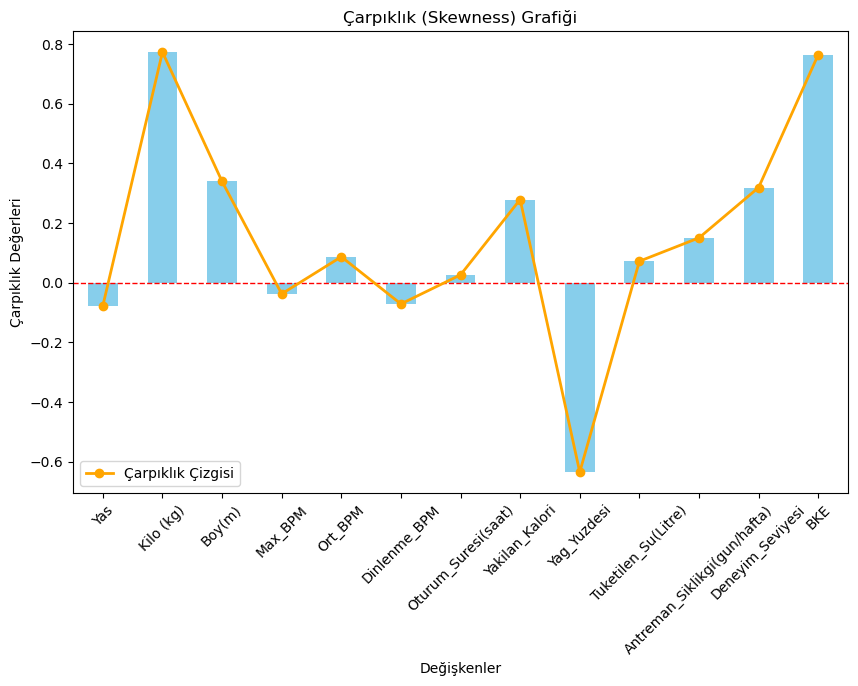

In [10]:

import matplotlib.pyplot as plt

# Çarpıklık değerlerini yazdırma ve görselleştirme
skewness = data.skew(numeric_only=True)

print("Çarpıklık (Skewness) Değerleri:")
print(skewness)

plt.figure(figsize=(10, 6))
bar_plot = skewness.plot(kind='bar', title="Çarpıklık (Skewness) Grafiği", color='skyblue')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel("Değişkenler")
plt.ylabel("Çarpıklık Değerleri")
plt.xticks(rotation=45)
plt.plot(skewness.index, skewness.values, color='orange', marker='o', linestyle='-', linewidth=2, label='Çarpıklık Çizgisi')
plt.legend()
plt.show()


Basıklık (Kurtosis) Değerleri:
Yas                            -1.215076
Kilo (kg)                      -0.023969
Boy(m)                         -0.723633
Max_BPM                        -1.187916
Ort_BPM                        -1.198724
Dinlenme_BPM                   -1.181466
Oturum_Suresi(saat)            -0.350805
Yakilan_Kalori                 -0.056050
Yag_Yuzdesi                    -0.339019
Tuketilen_Su(Litre)            -1.020298
Antreman_Siklikgi(gun/hafta)   -0.806101
Deneyim_Seviyesi               -1.123111
BKE                             0.743240
dtype: float64


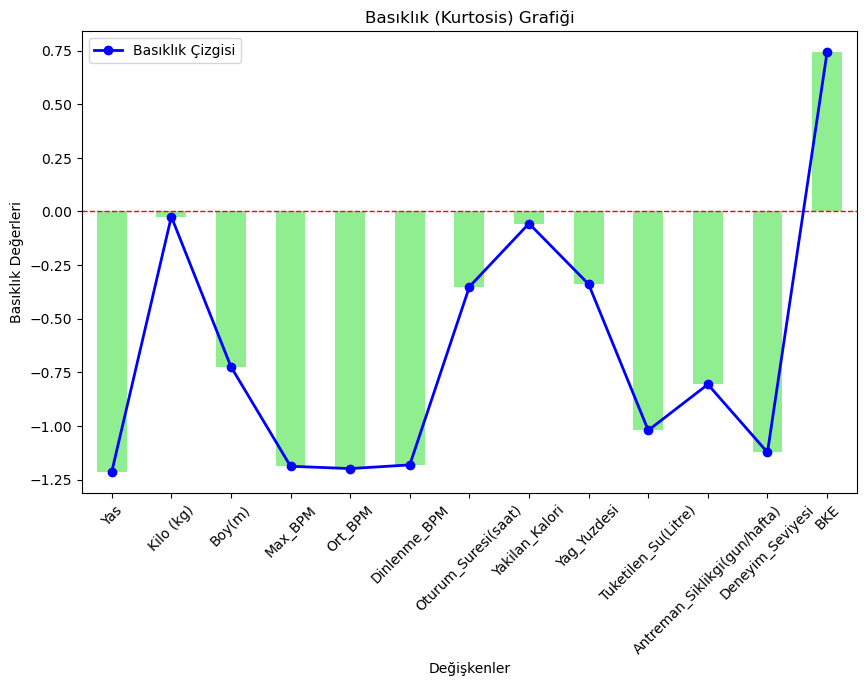

In [11]:
import matplotlib.pyplot as plt

# Basıklık (kurtosis) hesaplama
kurtosis = data.kurtosis(numeric_only=True)

# Basıklık değerlerini yazdırma ve görselleştirme
print("Basıklık (Kurtosis) Değerleri:")
print(kurtosis)

plt.figure(figsize=(10, 6))
bar_plot = kurtosis.plot(kind='bar', title="Basıklık (Kurtosis) Grafiği", color='lightgreen')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel("Değişkenler")
plt.ylabel("Basıklık Değerleri")
plt.xticks(rotation=45)
plt.plot(kurtosis.index, kurtosis.values, color='blue', marker='o', linestyle='-', linewidth=2, label='Basıklık Çizgisi')
plt.legend()
plt.show()

In [12]:
# Korelasyon Matrisleri
correlation_matrix = numeric_data.corr()

print("\nKorelasyon Matrisi:")
print(correlation_matrix)


Korelasyon Matrisi:
                                   Yas  Kilo (kg)    Boy(m)   Max_BPM  \
Yas                           1.000000  -0.036340 -0.027837 -0.017073   
Kilo (kg)                    -0.036340   1.000000  0.365321  0.057061   
Boy(m)                       -0.027837   0.365321  1.000000 -0.017660   
Max_BPM                      -0.017073   0.057061 -0.017660  1.000000   
Ort_BPM                       0.035969   0.009717 -0.014776 -0.039751   
Dinlenme_BPM                  0.004354  -0.032138 -0.005090  0.036647   
Oturum_Suresi(saat)          -0.019912  -0.013666 -0.010206  0.010051   
Yakilan_Kalori               -0.154679   0.095443  0.086348  0.002090   
Yag_Yuzdesi                   0.002370  -0.225512 -0.235521 -0.009056   
Tuketilen_Su(Litre)           0.041528   0.394276  0.393533  0.031621   
Antreman_Siklikgi(gun/hafta)  0.008055  -0.011769 -0.011270 -0.029099   
Deneyim_Seviyesi             -0.018676   0.003379 -0.010267  0.000545   
BKE                          -

In [13]:
# 'Egzerisz Türleri ' değişkeni için gözlemlenen frekansları hesapla
observed = data['Egzersiz_Turu'].value_counts()
observed

Egzersiz_Turu
Strength    258
Cardio      255
Yoga        239
HIIT        221
Name: count, dtype: int64

In [14]:
dict = {'Strength' : .25,
        'Cardio' : .25,
        'Yoga' : .25,
        'HIIT': .25}
   
probabilities = pd.Series(dict)
probabilities

Strength    0.25
Cardio      0.25
Yoga        0.25
HIIT        0.25
dtype: float64

In [15]:
N=973
expected = N * probabilities
expected

Strength    243.25
Cardio      243.25
Yoga        243.25
HIIT        243.25
dtype: float64

In [6]:
observed-expected

Egzersiz_Turu
Strength    14.75
Cardio      11.75
Yoga        -4.25
HIIT       -22.25
dtype: float64

In [7]:
(observed - expected)**2

Egzersiz_Turu
Strength    217.5625
Cardio      138.0625
Yoga         18.0625
HIIT        495.0625
dtype: float64

In [8]:
(observed - expected)**2 / expected

Egzersiz_Turu
Strength    0.894399
Cardio      0.567575
Yoga        0.074255
HIIT        2.035200
dtype: float64

In [9]:
sum((observed - expected)**2/expected)

3.5714285714285716

In [10]:
from scipy.stats import chi2
round(chi2.ppf(0.95, 3),2)

7.81

In [11]:
from scipy.stats import chisquare
chisquare(f_obs = observed, f_exp = expected)

Power_divergenceResult(statistic=3.5714285714285716, pvalue=0.3116155523686131)

In [12]:
#13.1 (χ²) Ki-Kare Test İstatistiği:

import pandas as pd
from scipy.stats import chisquare

# Gözlenen frekanslar (Cinsiyet dağılımı)
observed = data['Egzersiz_Turu'].value_counts()

# Beklenen frekanslar (eşit dağılım varsayımı)
expected= [len(data) / len(observed)] * len(observed)

# Ki-Kare uyum iyiliği testi
chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

# Sonuçları yazdırma
print(f"Ki-Kare Test İstatistiği (χ²): {chi2_stat}")
print(f"p-Değeri: {p_value}")

# Hipotez testi sonucu
if p_value < 0.05:
    print("Sonuç: Gözlenen sıklık ile beklenen sıklık arasında istatistiksel olarak anlamlı bir fark vardır.")
else:
    print("Sonuç: Gözlenen sıklık ile beklenen sıklık arasında istatistiksel olarak anlamlı bir fark yoktur.")


Ki-Kare Test İstatistiği (χ²): 3.5714285714285716
p-Değeri: 0.3116155523686131
Sonuç: Gözlenen sıklık ile beklenen sıklık arasında istatistiksel olarak anlamlı bir fark yoktur.


In [13]:
dict = {'Strength' : .20,
        'Cardio' : .15,
        'Yoga' : .25,
        'HIIT': .40}
   
probabilities = pd.Series(dict)
probabilities
expected = probabilities * sum(observed)
print(expected)

Strength    194.60
Cardio      145.95
Yoga        243.25
HIIT        389.20
dtype: float64


In [14]:
import pandas as pd
from scipy.stats import chisquare

# Gözlenen frekanslar (Cinsiyet dağılımı)
observed = data['Egzersiz_Turu'].value_counts()

#beklenen frekansı yeni olasılıklara göre hesapla
expected = probabilities * sum(observed)

# Ki-Kare uyum iyiliği testi
chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

# Sonuçları yazdırma
print(f"Ki-Kare Test İstatistiği (χ²): {chi2_stat}")
print(f"p-Değeri: {p_value}")

Ki-Kare Test İstatistiği (χ²): 174.89979445015422
p-Değeri: 1.1137534304716296e-37


In [22]:
pd.crosstab(index=data["Egzersiz_Turu"], columns=data["Antreman_Siklikgi(gun/hafta)"],margins=False)

Antreman_Siklikgi(gun/hafta),2,3,4,5
Egzersiz_Turu,,,,
Cardio,63,92,77,23
HIIT,42,86,67,26
Strength,45,102,85,26
Yoga,47,88,77,27


In [23]:
pd.crosstab(index=data["Egzersiz_Turu"], columns=data["Antreman_Siklikgi(gun/hafta)"],margins=True)

Antreman_Siklikgi(gun/hafta),2,3,4,5,All
Egzersiz_Turu,,,,,
Cardio,63,92,77,23,255
HIIT,42,86,67,26,221
Strength,45,102,85,26,258
Yoga,47,88,77,27,239
All,197,368,306,102,973


In [25]:
# 13.2 (χ²) Ki-Kare Bağımszılık veya (İlişki) Testi: 

import pandas as pd
from scipy.stats import chi2_contingency

# Çapraz tablo oluşturma
contingency_table = pd.crosstab(index=data['Antreman_Siklikgi(gun/hafta)'], columns=data['Egzersiz_Turu'])

# Bağımsızlık testi için ki-kare testi
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Sonuçları yazdırma
print("Çapraz Tablo:")
print(contingency_table)

print("\nChi2 Test İstatistiği:", chi2)
print("p-Değeri:", p)
print("Serbestlik Dereceleri:", dof)

print("\nBeklenen Frekanslar:")
print(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns))

# Hipotez sonucu
if p < 0.05:
    print("Sonuç: Antreman Sıklığı ve egzersiz türü birbirinden bağımsızdır.")
else:
    print("Sonuç: Antreman Sıklığı ve egzersiz türü birbirinden bağımsız değildir.")

Çapraz Tablo:
Egzersiz_Turu                 Cardio  HIIT  Strength  Yoga
Antreman_Siklikgi(gun/hafta)                              
2                                 63    42        45    47
3                                 92    86       102    88
4                                 77    67        85    77
5                                 23    26        26    27

Chi2 Test İstatistiği: 5.758264072995584
p-Değeri: 0.763847231607104
Serbestlik Dereceleri: 9

Beklenen Frekanslar:
Egzersiz_Turu                    Cardio       HIIT   Strength       Yoga
Antreman_Siklikgi(gun/hafta)                                            
2                             51.628983  44.745118  52.236382  48.389517
3                             96.443988  83.584789  97.578623  90.392600
4                             80.195272  69.502569  81.138746  75.163412
5                             26.731757  23.167523  27.046249  25.054471
Sonuç: Antreman Sıklığı ve egzersiz türü birbirinden bağımsız değildir.


In [28]:
import pandas as pd
import pingouin as pg

# Çapraz tabloyu oluşturma
observed = pd.crosstab(index=data["Antreman_Siklikgi(gun/hafta)"], columns=data["Egzersiz_Turu"],  margins=False)

# Pingouin kullanarak bağımsızlık testi
expected, observed, stats = pg.chi2_independence(data, x='Antreman_Siklikgi(gun/hafta)',  y='Egzersiz_Turu')

# Sonuçların yazdırılması
print("Pingouin ile Hesaplanan Gözlenen Frekanslar:")
print(observed)

print("\nPingouin ile Hesaplanan Beklenen Frekanslar:")
print(expected)

print("\nPingouin Test İstatistikleri:")
print(stats)


Pingouin ile Hesaplanan Gözlenen Frekanslar:
Egzersiz_Turu                 Cardio  HIIT  Strength  Yoga
Antreman_Siklikgi(gun/hafta)                              
2                                 63    42        45    47
3                                 92    86       102    88
4                                 77    67        85    77
5                                 23    26        26    27

Pingouin ile Hesaplanan Beklenen Frekanslar:
Egzersiz_Turu                    Cardio       HIIT   Strength       Yoga
Antreman_Siklikgi(gun/hafta)                                            
2                             51.628983  44.745118  52.236382  48.389517
3                             96.443988  83.584789  97.578623  90.392600
4                             80.195272  69.502569  81.138746  75.163412
5                             26.731757  23.167523  27.046249  25.054471

Pingouin Test İstatistikleri:
                 test    lambda      chi2  dof      pval    cramer     power
0        

In [29]:
#13.6 Fisher Kesin Testi

import pandas as pd
from scipy.stats import fisher_exact

# Çapraz tablo oluşturma
contingency_table = pd.crosstab(index=data['Cinsiyet'], columns=data['Egzersiz_Turu'])

# Cardio ve HIIT Kategorilerini seçip 2x2 lik tabloya indirgeme 
contingency_table_2x2 = contingency_table.loc[['Male', 'Female'], ['Cardio', 'HIIT']]

# Fisher Kesin Testi
oddsratio, p_value = fisher_exact(contingency_table_2x2)

# Tabloyu ve sonuçları yazdırma
print("2x2 Çapraz Tablo:")
print(contingency_table_2x2)
print("\nFisher Kesin Testi Sonuçları:")
print("Odds Oranı:", oddsratio)
print("p-Değeri:", p_value)

# Hipotez sonucu
if p_value < 0.05:
    print("Sonuç: İki değişken arasında istatistiksel olarak anlamlı bir ilişki vardır.")
else:
    print("Sonuç: İki değişken arasında istatistiksel olarak anlamlı bir ilişki yoktur.")

2x2 Çapraz Tablo:
Egzersiz_Turu  Cardio  HIIT
Cinsiyet                   
Male              129   114
Female            126   107

Fisher Kesin Testi Sonuçları:
Odds Oranı: 0.9609440267335004
p-Değeri: 0.8544090398364391
Sonuç: İki değişken arasında istatistiksel olarak anlamlı bir ilişki yoktur.


In [30]:
#13.7 McNemar Testi

import pandas as pd
import pingouin as pg

# Dinlenme BPM ve Max BPM için eşik değer belirleme
dinlenme_threshold = 60
max_threshold = 160

# İkili bir değişken oluşturma: Dinlenme ve Max BPM eşik üstünde mi?
data['Dinlenme_Yuksek'] = (data['Dinlenme_BPM'] > dinlenme_threshold).astype(int)
data['Max_Yuksek'] = (data['Max_BPM'] > max_threshold).astype(int)

# "birinci_faktör" ve "ikinci_faktör" sütunlarını oluşturma
data['birinci_faktör'] = data['Dinlenme_Yuksek']
data['ikinci_faktör'] = data['Max_Yuksek']

# Pingouin McNemar testi
observed, stats = pg.chi2_mcnemar(data, 'birinci_faktör', 'ikinci_faktör')

# Sonuçları yazdırma
print(f"Belirlenen eşik değerler:\nDinlenme_BPM: {dinlenme_threshold}, Max_BPM: {max_threshold}")
print("\nÇapraz Tablo (Observed):")
print(observed)

print("\nMcNemar Testi Sonuçları:")
print(stats)


Belirlenen eşik değerler:
Dinlenme_BPM: 60, Max_BPM: 160

Çapraz Tablo (Observed):
ikinci_faktör   0    1
birinci_faktör        
0               9  402
1               9  553

McNemar Testi Sonuçları:
               chi2  dof      p-approx        p-exact
mcnemar  373.878345    1  2.677749e-83  3.265826e-106
